In [7]:
#Import libraries
import sqlite3
import pandas as pd

In [8]:
#Create database inside sql folder
#cursor = pen that writes SQL commands.
conn = sqlite3.connect('retail_pulse.db')
cursor = conn.cursor()
print("Database created successfully!")

Database created successfully!


In [9]:
#CREATE CUSTOMERS TABLE (''' = allows writing on multiple lines)
#PRIMARY KEY = unique ID for each customers, no duplicates allowed.
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
    customer_id INT PRIMARY KEY,
    name TEXT NOT NULL,
    email TEXT,
    city TEXT,
    segment TEXT,
    join_date TEXT
)
''')

In [10]:
#CREATE PRODUCTS TABLE
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_id INT PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT,
    cost REAL,
    price REAL
)
''')

In [12]:
#CREATE ORDERS TABLE
cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    order_id INT PRIMARY KEY,
    customer_id INT,
    order_date TEXT,
    status TEXT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
''')

In [13]:
#CREATE ORDER_ITEMS TABLE
cursor.execute('''
CREATE TABLE IF NOT EXISTS order_items (
    item_id INT PRIMARY KEY,
    order_id INT,
    product_id INT,
    quantity INT,
    unit_price REAL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
)
''')
conn.commit()
print("All tables created successfully!")

All tables created successfully!


In [14]:
#INSERT SAMPLE CUSTOMERS
customers_data = [
    (1, 'Sakshi Dwivedi', 'sakshi@gmail.com', 'Mumbai', 'Premium', '2024-01-15'),
    (2, 'Raj Sharma', 'raj@gmail.com', 'Delhi', 'Regular', '2024-02-20'),
    (3, 'Priya Patel', 'priya@gamil.com', 'Bangalore', 'Premium', '2024-01-05'),
    (4, 'Amit Singh', 'amit@gmail.com', 'Bangalore', 'Premium', '2024-01-05'),
    (5, 'Neha Gupta', 'neha@gmail.com', 'Pune', 'Regular', '2024-04-18'),
]

cursor.executemany('''
INSERT OR IGNORE INTO customers
VALUES (?,?,?,?,?,?)
''', customers_data)

conn.commit()
print("Customers inserted successfully!")
    

Customers inserted successfully!


In [17]:
#Insert sample products
products_data = [
    (1, 'Running Shoes', 'Footwear', 800.00, 1499.99),
    (2, 'Cotton T-Shirt', 'Clothing', 150.00, 299.99),
    (3, 'Leather Bag', 'Accessories', 500.00, 999.99),
    (4, 'Sunglasses', 'Accessories', 200.00, 449.99),
    (5, 'Denim Jeans', 'Clothing', 400.00, 799.99),
    (6, 'Sports Watch', 'Electronics', 1200.00, 2499.99),
    (7, 'Backpack', 'Accessories', 350.00, 699.99),
    (8, 'Formal Shirt', 'Clothing', 300.00, 599.99),
]

cursor.executemany('''
INSERT OR IGNORE INTO products 
VALUES (?,?,?,?,?)
''', products_data)

conn.commit()
print("Products inserted successfully!")

Products inserted successfully!


In [19]:
# Insert sample orders
orders_data = [
    (1, 1, '2024-01-20', 'Delivered'),
    (2, 2, '2024-02-25', 'Delivered'),
    (3, 3, '2024-03-15', 'Cancelled'),
    (4, 4, '2024-01-10', 'Delivered'),
    (5, 5, '2024-04-20', 'Delivered'),
    (6, 1, '2024-02-10', 'Delivered'),
    (7, 2, '2024-03-05', 'Returned'),
    (8, 4, '2024-02-28', 'Delivered'),
    (9, 3, '2024-04-01', 'Delivered'),
    (10, 5, '2024-05-10', 'Delivered'),
]

cursor.executemany('''
INSERT OR IGNORE INTO orders 
VALUES (?,?,?,?)
''', orders_data)

conn.commit()
print(" Orders inserted successfully!")

 Orders inserted successfully!


In [20]:
# Insert sample order items
order_items_data = [
    (1, 1, 1, 2, 1499.99),
    (2, 1, 3, 1, 999.99),
    (3, 2, 2, 3, 299.99),
    (4, 3, 4, 1, 449.99),
    (5, 4, 6, 1, 2499.99),
    (6, 5, 5, 2, 799.99),
    (7, 6, 7, 1, 699.99),
    (8, 7, 2, 2, 299.99),
    (9, 8, 8, 3, 599.99),
    (10, 9, 1, 1, 1499.99),
    (11, 10, 3, 2, 999.99),
    (12, 6, 5, 1, 799.99),
]

cursor.executemany('''
INSERT OR IGNORE INTO order_items 
VALUES (?,?,?,?,?)
''', order_items_data)

conn.commit()
print(" Order items inserted successfully!")

 Order items inserted successfully!


In [23]:
# Verify all data
print("=== CUSTOMERS ===")
df_customers = pd.read_sql_query("SELECT * FROM customers", conn)
print(df_customers)

print("\n=== PRODUCTS ===")
df_products = pd.read_sql_query("SELECT * FROM products", conn)
print(df_products)

print("\n=== ORDERS ===")
df_orders = pd.read_sql_query("SELECT * FROM orders", conn)
print(df_orders)

print("\n=== ORDER ITEMS ===")
df_items = pd.read_sql_query("SELECT * FROM order_items", conn)
print(df_items)

=== CUSTOMERS ===
   customer_id            name             email       city  segment  \
0            1  Sakshi Dwivedi  sakshi@gmail.com     Mumbai  Premium   
1            2      Raj Sharma     raj@gmail.com      Delhi  Regular   
2            3     Priya Patel   priya@gamil.com  Bangalore  Premium   
3            4      Amit Singh    amit@gmail.com  Bangalore  Premium   
4            5      Neha Gupta    neha@gmail.com       Pune  Regular   

    join_date  
0  2024-01-15  
1  2024-02-20  
2  2024-01-05  
3  2024-01-05  
4  2024-04-18  

=== PRODUCTS ===
   product_id    product_name     category    cost    price
0           1   Running Shoes     Footwear   800.0  1499.99
1           2  Cotton T-Shirt     Clothing   150.0   299.99
2           3     Leather Bag  Accessories   500.0   999.99
3           4      Sunglasses  Accessories   200.0   449.99
4           5     Denim Jeans     Clothing   400.0   799.99
5           6    Sports Watch  Electronics  1200.0  2499.99
6           7  

In [24]:
# Query 1 - Total Revenue
print("=== TOTAL REVENUE ===")
df_revenue = pd.read_sql_query('''
SELECT 
    ROUND(SUM(quantity * unit_price), 2) as total_revenue,
    COUNT(DISTINCT order_id) as total_orders,
    ROUND(AVG(quantity * unit_price), 2) as avg_order_value
FROM order_items
''', conn)
print(df_revenue)

=== TOTAL REVENUE ===
   total_revenue  total_orders  avg_order_value
0        16849.8            10          1404.15


In [25]:
# Query 2 - Revenue by Category
print("=== REVENUE BY CATEGORY ===")
df_category = pd.read_sql_query('''
SELECT 
    p.category,
    COUNT(oi.order_id) as total_orders,
    SUM(oi.quantity) as total_items_sold,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) as total_revenue,
    ROUND(AVG(oi.unit_price), 2) as avg_price
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC
''', conn)
print(df_category)

=== REVENUE BY CATEGORY ===
      category  total_orders  total_items_sold  total_revenue  avg_price
0     Clothing             5                11        5699.89     559.99
1     Footwear             2                 3        4499.97    1499.99
2  Accessories             4                 5        4149.95     787.49
3  Electronics             1                 1        2499.99    2499.99


In [26]:
# Query 3 - Top Customers by Revenue
print("=== TOP CUSTOMERS ===")
df_top_customers = pd.read_sql_query('''
SELECT 
    c.customer_id,
    c.name,
    c.city,
    c.segment,
    COUNT(DISTINCT o.order_id) as total_orders,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) as total_spent
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = "Delivered"
GROUP BY c.customer_id
ORDER BY total_spent DESC
''', conn)
print(df_top_customers)

=== TOP CUSTOMERS ===
   customer_id            name       city  segment  total_orders  total_spent
0            1  Sakshi Dwivedi     Mumbai  Premium             2      5499.95
1            4      Amit Singh  Bangalore  Premium             2      4299.96
2            5      Neha Gupta       Pune  Regular             2      3599.96
3            3     Priya Patel  Bangalore  Premium             1      1499.99
4            2      Raj Sharma      Delhi  Regular             1       899.97


In [27]:
# Query 4 - Monthly Sales Trend
print("=== MONTHLY SALES TREND ===")
df_monthly = pd.read_sql_query('''
SELECT 
    strftime("%Y-%m", o.order_date) as month,
    COUNT(DISTINCT o.order_id) as total_orders,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) as monthly_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = "Delivered"
GROUP BY month
ORDER BY month ASC
''', conn)
print(df_monthly)

=== MONTHLY SALES TREND ===
     month  total_orders  monthly_revenue
0  2024-01             2          6499.96
1  2024-02             3          4199.92
2  2024-04             2          3099.97
3  2024-05             1          1999.98


In [28]:
# Query 5 - RFM Analysis
print("=== RFM ANALYSIS ===")
df_rfm = pd.read_sql_query('''
SELECT 
    c.customer_id,
    c.name,
    c.segment,
    -- Recency: days since last order
    ROUND(julianday("2024-06-01") - 
    MAX(julianday(o.order_date)), 0) as recency_days,
    -- Frequency: number of orders
    COUNT(DISTINCT o.order_id) as frequency,
    -- Monetary: total amount spent
    ROUND(SUM(oi.quantity * oi.unit_price), 2) as monetary
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = "Delivered"
GROUP BY c.customer_id
ORDER BY monetary DESC
''', conn)
print(df_rfm)

=== RFM ANALYSIS ===
   customer_id            name  segment  recency_days  frequency  monetary
0            1  Sakshi Dwivedi  Premium         112.0          2   5499.95
1            4      Amit Singh  Premium          94.0          2   4299.96
2            5      Neha Gupta  Regular          22.0          2   3599.96
3            3     Priya Patel  Premium          61.0          1   1499.99
4            2      Raj Sharma  Regular          97.0          1    899.97


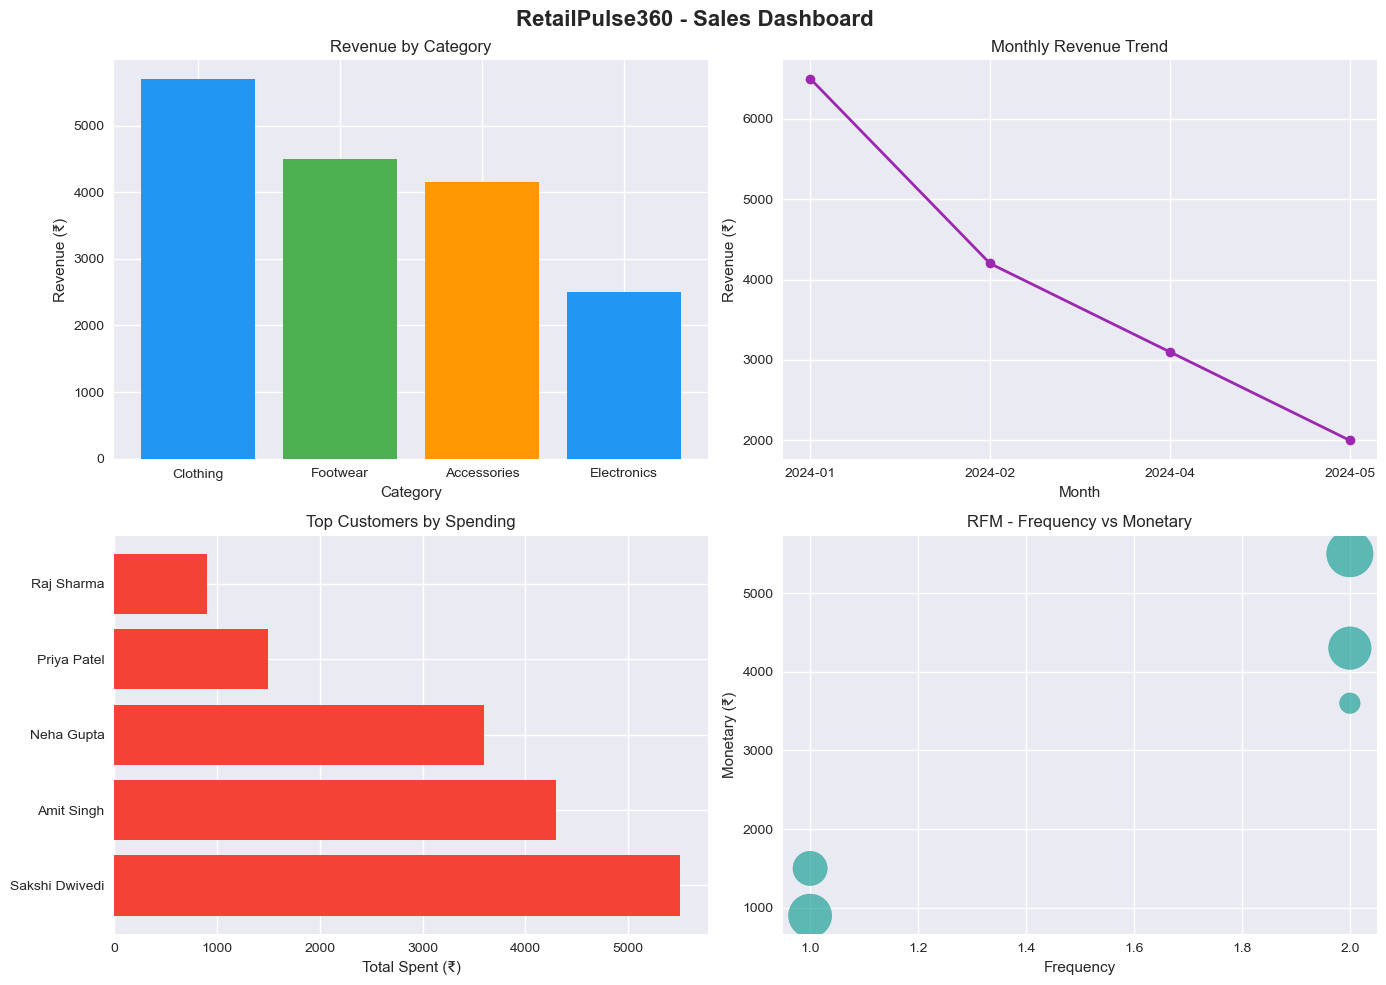

 Charts saved successfully!


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RetailPulse360 - Sales Dashboard', 
             fontsize=16, fontweight='bold')

# Chart 1 - Revenue by Category
axes[0,0].bar(df_category['category'], 
              df_category['total_revenue'],
              color=['#2196F3','#4CAF50','#FF9800'])
axes[0,0].set_title('Revenue by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Revenue (₹)')

# Chart 2 - Monthly Revenue
axes[0,1].plot(df_monthly['month'], 
               df_monthly['monthly_revenue'],
               marker='o', color='#9C27B0', linewidth=2)
axes[0,1].set_title('Monthly Revenue Trend')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Revenue (₹)')

# Chart 3 - Top Customers
axes[1,0].barh(df_top_customers['name'],
               df_top_customers['total_spent'],
               color='#F44336')
axes[1,0].set_title('Top Customers by Spending')
axes[1,0].set_xlabel('Total Spent (₹)')

# Chart 4 - RFM Monetary
axes[1,1].scatter(df_rfm['frequency'],
                  df_rfm['monetary'],
                  s=df_rfm['recency_days']*10,
                  color='#009688', alpha=0.6)
axes[1,1].set_title('RFM - Frequency vs Monetary')
axes[1,1].set_xlabel('Frequency')
axes[1,1].set_ylabel('Monetary (₹)')

plt.tight_layout()
plt.savefig('../docs/dashboard_preview.png')
plt.show()
print(" Charts saved successfully!")